# EDF to Jupyter Explorer

Load an EDF file from a local path, inspect the recording, and convert manageable sections into formats that are convenient for notebook exploration.

The notebook keeps the full recording as an `mne.io.Raw` object and creates smaller `pandas`/`xarray` views for interactive work. This avoids accidentally turning a very large EDF into an enormous in-memory table.

## 1. Imports

Install missing packages in your environment if needed:

```bash
pip install mne pandas numpy matplotlib xarray ipywidgets mne-qt-browser PyQt6
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import mne
except ImportError as exc:
    raise ImportError("Install MNE first: pip install mne") from exc

try:
    import xarray as xr
except ImportError:
    xr = None

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 20)

mne.set_log_level("INFO")

## 2. Choose EDF Path

Set `EDF_PATH` to the file you want to explore. Use `get_rawdata_root()` from `scripts.io.repository_paths` to start from the active machine-specific data-location profile.

In [13]:
EDF_PATH = Path("/mnt/harris/hypnose/hypnose_eeg/rawdata/sub-063_id-430/ses-001_date-20260715/ephys/sub-063_ses-001_recording-concat.edf")

if not EDF_PATH.exists():
    raise FileNotFoundError(f"EDF file not found: {EDF_PATH.resolve()}")

EDF_PATH.resolve()

PosixPath('/mnt/harris/hypnose/hypnose_eeg/rawdata/sub-063_id-430/ses-001_date-20260715/ephys/sub-063_ses-001_recording-concat.edf')

## 3. Load EDF as MNE Raw

`raw` is the best primary format for EEG exploration in Python because it preserves channel metadata, sampling rate, annotations, and plotting utilities.

Use `preload=False` first for large EDF files. You can crop and load smaller sections later.

In [14]:
raw = mne.io.read_raw_edf(
    EDF_PATH,
    preload=False,
    infer_types=True,
    verbose=True,
)

raw

Extracting EDF parameters from /mnt/harris/hypnose/hypnose_eeg/rawdata/sub-063_id-430/ses-001_date-20260715/ephys/sub-063_ses-001_recording-concat.edf...
Setting channel info structure...
Creating raw.info structure...


<RawEDF | sub-063_ses-001_recording-concat.edf, 3 x 222230016 (434043.0 s), ~7 KiB, data not loaded>

## 4. Recording Summary

In [15]:
summary = {
    "file": str(EDF_PATH),
    "n_channels": len(raw.ch_names),
    "sampling_rate_hz": raw.info["sfreq"],
    "n_samples": raw.n_times,
    "duration_seconds": raw.n_times / raw.info["sfreq"],
    "duration_hours": raw.n_times / raw.info["sfreq"] / 3600,
    "meas_date": raw.info.get("meas_date"),
}

pd.Series(summary)

file                /mnt/harris/hypnose/hypnose_eeg/rawdata/sub-06...
n_channels                                                          3
sampling_rate_hz                                                512.0
n_samples                                                   222230016
duration_seconds                                             434043.0
duration_hours                                               120.5675
meas_date                                   2026-07-15 11:03:55+00:00
dtype: object

In [16]:
channel_table = pd.DataFrame({
    "channel": raw.ch_names,
    "type": raw.get_channel_types(),
})

channel_table

,channel,type
0,EEG1A-B,eeg
1,EEG2A-B,eeg
2,EMG,eeg


## 5. Annotations and Events

EDF files may include sleep stages, markers, or other annotations. This cell converts annotations to a table when present.

In [17]:
annotations_df = pd.DataFrame({
    "onset_seconds": raw.annotations.onset,
    "duration_seconds": raw.annotations.duration,
    "description": raw.annotations.description,
})

annotations_df

,onset_seconds,duration_seconds,description
0,21310.0,0.0,BAD boundary
1,21310.0,0.0,EDGE boundary
2,21310.0,149.0,BAD_ACQ_SKIP_CONCAT_GAP 149.000s
3,21459.0,0.0,BAD boundary
4,21459.0,0.0,CONCAT_BOUNDARY sub-063_ses-001_recording-001_...
5,21459.0,0.0,EDGE boundary
6,170879.0,0.0,BAD boundary
7,170879.0,0.0,BAD boundary
8,170879.0,0.0,EDGE boundary
9,170879.0,0.0,EDGE boundary


## 6. Pick Channels and Time Window

Create a smaller loaded view for notebook exploration. Adjust `START_SECONDS`, `DURATION_SECONDS`, and `CHANNELS`.

In [7]:
START_SECONDS = 0
DURATION_SECONDS = 60

# Use None for all channels, or provide names such as ["C3", "C4", "O1", "O2"].
CHANNELS = None

tmin = START_SECONDS
tmax = START_SECONDS + DURATION_SECONDS

raw_window = raw.copy().crop(tmin=tmin, tmax=tmax, include_tmax=False)

if CHANNELS is not None:
    raw_window.pick(CHANNELS)

raw_window.load_data()
raw_window

Reading 0 ... 30719  =      0.000 ...    59.998 secs...


<RawEDF | sub-063_ses-001_recording-concat.edf, 3 x 30720 (60.0 s), ~727 KiB, data loaded>

## 7. Convert Window to Pandas

Wide format is convenient for plotting and quick inspection: one row per time point, one column per channel.

In [9]:
data, times = raw_window.get_data(return_times=True)

edf_wide_df = pd.DataFrame(data.T, columns=raw_window.ch_names)
edf_wide_df.insert(0, "time_seconds", times + START_SECONDS)

edf_wide_df.head()

,time_seconds,EEG1A-B,EEG2A-B,EMG
0,0.000000,-0.000059,-0.000184,-0.000119
1,0.001953,-0.000045,-0.000017,-0.000119
2,0.003906,-0.000032,0.000014,-0.000101
3,0.005859,-0.000029,0.000015,-0.000002
4,0.007812,-0.000029,0.000015,0.000039


In [10]:
edf_long_df = edf_wide_df.melt(
    id_vars="time_seconds",
    var_name="channel",
    value_name="value",
)

edf_long_df.head()

,time_seconds,channel,value
0,0.000000,EEG1A-B,-0.000059
1,0.001953,EEG1A-B,-0.000045
2,0.003906,EEG1A-B,-0.000032
3,0.005859,EEG1A-B,-0.000029
4,0.007812,EEG1A-B,-0.000029


## 8. Convert Window to Xarray

`xarray` is useful for labeled multidimensional data. The output has dimensions `channel` and `time_seconds`.

In [11]:
if xr is None:
    print("xarray is not installed. Install with: pip install xarray")
else:
    edf_xr = xr.DataArray(
        data,
        dims=("channel", "time_seconds"),
        coords={
            "channel": raw_window.ch_names,
            "time_seconds": times + START_SECONDS,
        },
        attrs={
            "source_file": str(EDF_PATH),
            "sampling_rate_hz": raw_window.info["sfreq"],
            "units": "MNE default SI units, usually volts for EEG",
        },
        name="edf_signal",
    )
    display(edf_xr)

<xarray.DataArray 'edf_signal' (channel: 3, time_seconds: 30720)> Size: 737kB
array([[-5.92279870e-05, -4.54226831e-05, -3.20566390e-05, ...,
         1.67011840e-05,  2.13447862e-05,  2.13447862e-05],
       [-1.84165986e-04, -1.73728159e-05,  1.35008636e-05, ...,
         8.14606092e-05,  8.13351064e-05,  8.13351064e-05],
       [-1.18960878e-04, -1.18960878e-04, -1.01348400e-04, ...,
         7.07916004e-05,  7.07916004e-05,  7.07916004e-05]])
Coordinates:
  * channel       (channel) <U7 84B 'EEG1A-B' 'EEG2A-B' 'EMG'
  * time_seconds  (time_seconds) float64 246kB 0.0 0.001953 ... 60.0 60.0
Attributes:
    source_file:       /mnt/harris/hypnose/hypnose_eeg/rawdata/sub-063_id-430...
    sampling_rate_hz:  512.0
    units:             MNE default SI units, usually volts for EEG

## 9. Quick Plots

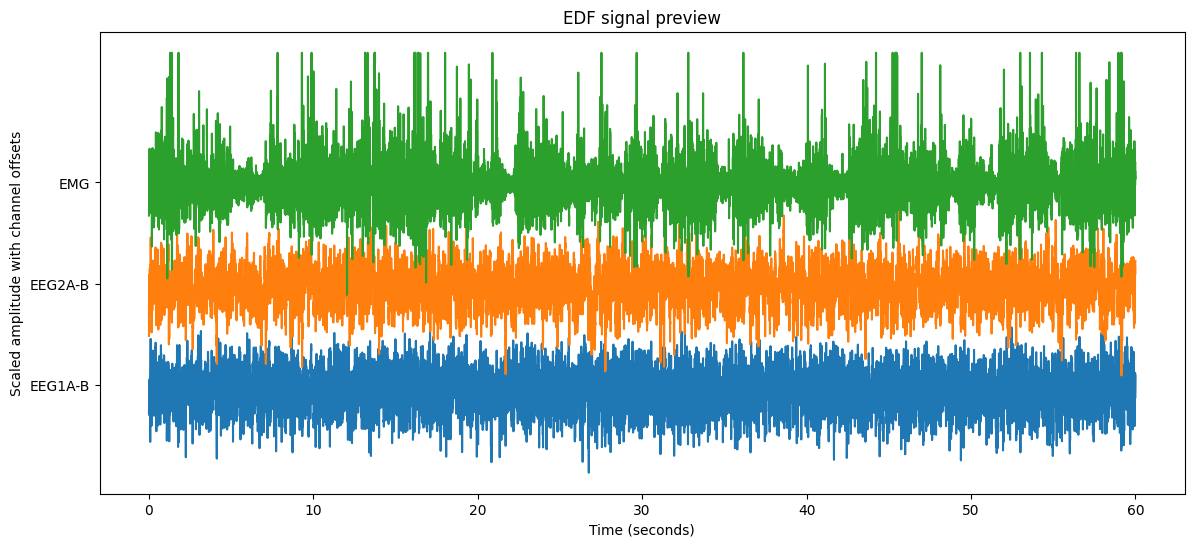

In [12]:
plot_channels = raw_window.ch_names[: min(8, len(raw_window.ch_names))]

fig, ax = plt.subplots(figsize=(14, 6))
channel_spacing = 5.0
yticks = []

for channel_index, channel in enumerate(plot_channels):
    values = edf_wide_df[channel].to_numpy()
    scale = np.nanstd(values) or 1.0
    offset = channel_index * channel_spacing
    ax.plot(edf_wide_df["time_seconds"], values / scale + offset, label=channel)
    yticks.append(offset)

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Scaled amplitude with channel offsets")
ax.set_yticks(yticks)
ax.set_yticklabels(plot_channels)
ax.set_title("EDF signal preview")
plt.show()

In [ ]:
# MNE's built-in browser is often the best interactive view.
# The Qt backend opens a separate interactive browser window from Jupyter.
# 
try:
    get_ipython().run_line_magic("gui", "qt")
except NameError:
    pass

try:
    mne.viz.set_browser_backend("qt")
except Exception as exc:
    raise RuntimeError("Install the interactive MNE browser with: pip install mne-qt-browser PyQt6") from exc

channel_types = raw_window.get_channel_types()
mne_scalings = {}

for channel_type in sorted(set(channel_types)):
    picks = [idx for idx, kind in enumerate(channel_types) if kind == channel_type]
    values = raw_window.get_data(picks=picks)
    scale = np.nanpercentile(np.abs(values), 95) * 2
    mne_scalings[channel_type] = max(scale, 1e-12)

raw_window.plot(
    duration=min(30, DURATION_SECONDS),
    n_channels=min(20, len(raw_window.ch_names)),
    scalings=mne_scalings,
    butterfly=False,
    remove_dc=True,
    block=False,
)

Using qt as 2D backend.


Channels marked as bad:
none
Attempting to create new mne-python configuration file:
/Users/Volkan/.mne/mne-python.json
Could not read the /Users/Volkan/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)


## 10. Optional: Downsample for Faster Exploration

Downsampling is useful when plotting long windows or exporting compact notebook-friendly tables.

In [ ]:
TARGET_SFREQ = 100

raw_window_resampled = raw_window.copy().resample(TARGET_SFREQ)
resampled_data, resampled_times = raw_window_resampled.get_data(return_times=True)

edf_resampled_df = pd.DataFrame(resampled_data.T, columns=raw_window_resampled.ch_names)
edf_resampled_df.insert(0, "time_seconds", resampled_times + START_SECONDS)

edf_resampled_df.head()

## 11. Optional: Save Notebook-Friendly Outputs

Use these only for small windows or downsampled data. Saving full overnight EDF recordings as CSV can be very large.

In [ ]:
OUTPUT_DIR = Path("../data/processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

stem = EDF_PATH.stem

# CSV for quick inspection.
csv_path = OUTPUT_DIR / f"{stem}_window_{START_SECONDS}s_{DURATION_SECONDS}s_resampled.csv"
edf_resampled_df.to_csv(csv_path, index=False)

# FIF preserves MNE metadata better than CSV.
fif_path = OUTPUT_DIR / f"{stem}_window_{START_SECONDS}s_{DURATION_SECONDS}s_raw.fif"
raw_window.save(fif_path, overwrite=True)

csv_path, fif_path